In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from uncertainties import ufloat
from uncertainties import unumpy as unp

In [2]:
def theta(t, A, tau, w, phase, h):
        return A * np.exp(-t/tau) * np.sin(w*t + phase) + h

def lin(x,a,b):
        return a*x + b

def rotate_data(t, xdata, ydata):
    popt, pcov = curve_fit(lin, xdata=xdata, ydata=ydata)
    phi = np.arctan(popt[0])
    
    x = xdata * np.cos(-phi) - (ydata - popt[1]) * np.sin(-phi)
    y = xdata * np.sin(-phi) + (ydata - popt[1]) * np.cos(-phi)

    return x, y

def fit(t, xdata, ydata, p0: list = [180, 2000, 0.017, -1.5, 630], cutoff: int = 0):
    x, y = rotate_data(t, xdata, ydata)

    popt, pcov = curve_fit(theta, t[cutoff:], x[cutoff:], p0=p0)

    fig, (ax1, ax2) = plt.subplots(2, sharex=True)

    ax1.plot(t, x - popt[4], 'k.', ms=1)
    ax1.plot(t[cutoff:], theta(t[cutoff:], *popt) - popt[4], 'r')
    #ax1.set_xlabel('t')
    ax1.set_ylabel('x')

    ax2.errorbar(t, y, fmt='k.', capsize=1, linewidth=0.6, ms=0.8)
    ax2.set_xlabel('t')
    ax2.set_ylabel('y')

    #T = 2 * np.pi / ufloat(popt[2], pcov[2,2]**0.5)

    return unp.uarray(popt, np.sqrt(np.diag(pcov)))

In [3]:
def conversion(h1,h2):
    # known length of h, v in m
    l_h = unp.uarray(46.1, 0.1) #cm
    l_v = unp.uarray(32.8, 0.1) #cm
    
    #conversion factor calc + uncertainty

    #calculation
    #h_diff = h2-h1
    #v_diff = v2-v1
    # pixel conversion factors
    #x_px = l_h * unp.cos(unp.arctan(h_diff[0]/h_diff[1])) # m / fake m
    #y_px = l_v * unp.cos(unp.arctan(v_diff[1]/v_diff[0])) # m / fake m
    #print(h_diff)
    #print(h_diff[1])
    #print(h_diff[0])

    #print(conversion(h1,h2,v1,v2))
    l_h = unp.uarray(46.1, 0.1) #cm
    l_v = unp.uarray(32.8, 0.1) #cm
    
    alpha = unp.arctan( (h2[1]-h1[1])/(h2[0]-h1[0]) )
    H = (h2[1]-h1[1])/unp.sin(alpha)
    
    return l_h/H

In [4]:
# input data: virtual meters for h and v
# h
# NEW FOR EACH RUN:
h1 = unp.uarray([-295.6,-100.7], [10,10]) # coordinates in virt m 
h2 = unp.uarray([123.2,-104.9], [10,10]) # virt m
# v 
#v1 = unp.uarray([22.02,-794.6], [10,10]) # virt m
#v2 = unp.uarray([-16.84,-126.1], [10,10]) # virt m

print(conversion(h1,h2))

0.110+/-0.004


In [5]:
# calculate G , incl uncertainties
def G_12(theta1, theta2, T, conversion_factor):
    #technical drawing
    m = unp.uarray(0.028, 0)  #0.028 #kg tech drawing

    #I = m*l**2/2 #kg m^2, using MIT estimated formula
    l=unp.uarray(0.12, 0.001)-unp.uarray(0.0171, 0.001)
    #l=unp.uarray(0.12, 0.001)
    rk = unp.uarray(0.0171,0.00001)# radius of pendulum spheres
    #I = 2*m *( 2/5 * rk**2 + (l/2)**2)  #improvement of I
    I = m*l**2/2 #kg m^2, using MIT estimated formula
    
    # laser meas
    L =  unp.uarray(4.321, 0.001) #m
        
    #measured:
    M = unp.uarray(1.5,0.01)  #kg +/-10g
    
    #delta_r = 0.003 #possible systematic on r
    delta_r = 0.0
    r = unp.uarray(0.061  + delta_r, 0.005) #m  51.722+/-0.011 #meas with messschieber in the air, could be improved

        
    #fit: T0, dtheta1, dtheta2
    h1=theta1*conversion_factor #conversion factor for vid setup 1 in cm/'m'. used squared addition here
    h2=theta2*conversion_factor
    
    #dtheta= unp.arctan( (theta2 - theta1)*0.01 / 4.321) #0.01 go from cm to m
    dtheta= unp.arctan( ((h2 - h1)*0.5)*0.01 / 4.321) #0.01 go from cm to m
        
    #units kg m^2 /s^2  * m^2/kg^2/m
    G = (r)**2 * (l)/(8*M) * (2*np.pi/T)**2 * dtheta  #using MIT I that cancels, we could get a correction here

    print('eq1:',h1,'eq2:',h2, 'in cm')
    
    return G

period from zero measurement =  377.08+/-0.06


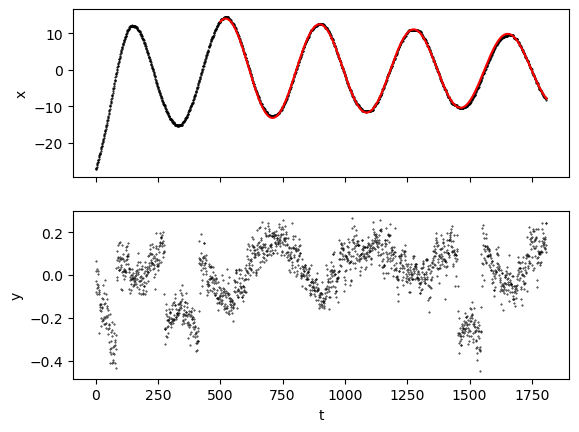

In [6]:
#get period T0
T =  2*np.pi/fit(*np.loadtxt('m5/m5_p0.txt', skiprows=2, unpack=True), cutoff=500)[2]
print('period from zero measurement = ', T)

eq1: 23.1+/-0.8 eq2: 26.2+/-0.9 in cm
(6.4+/-1.1)e-11


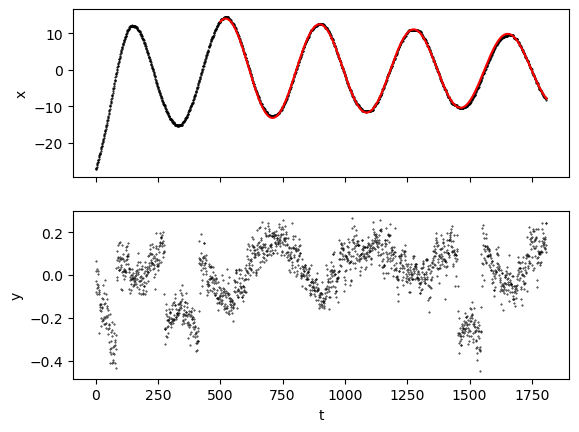

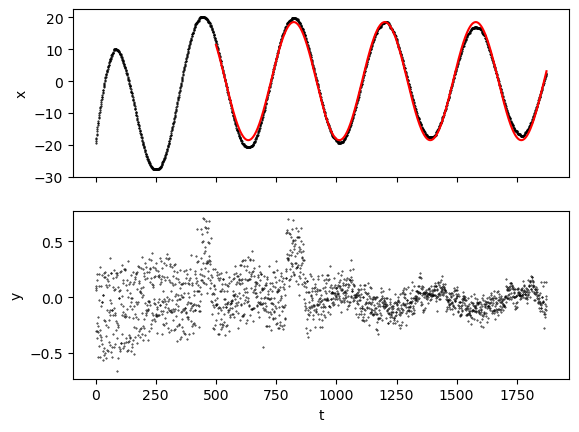

In [7]:
#T = ufloat(379.9587037978669, 0) # mean of both, in principle we have zero measurement for full glory
#fit: T0, dtheta1, dtheta2
#theta1=unp.uarray(1042.074833852749, 0 ) #conversion factor for vid setup 1 in cm/'m'. used squared addition here
#theta2=unp.uarray(1249.6597283089984, 0)
theta1 = fit(*np.loadtxt('m5/m5_p0.txt', skiprows=2, unpack=True), cutoff=500)[4]
theta2 = fit(*np.loadtxt('m5/m5_p2.txt', skiprows=2, unpack=True), cutoff=500)[4]
conversion_factor =conversion(h1,h2)
print(G_12(theta1, theta2, T, conversion_factor)*2) # *2 for G01,2 